**오늘의 학습 목표**
- Open Source LLM(ollama 활용) 로컬로 돌려보기
- gpu가 지금 없는 상태라 허깅페이스 등은 강의노트&강의 보면서 참고

**학습 날짜**
- 2026.05.14

In [7]:
%pip install -U ollama

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


#### 1. Ollama 사용하기
- Ollama 원본 API 직접 사용해보기

In [13]:
from ollama import chat
from ollama import ChatResponse

response: ChatResponse = chat(model='gemma3:4b', messages=[
  {
    'role': 'user',
    'content': '당신은 반도체 MES 엔지니어입니다. OHT 이상 알람이 발생했을 때 원인 후보를 단계적으로 추론해주세요.',
  },
],
    options={
        'temperature': 0.7,       # 창의성 조절 (0.0 ~ 1.0)
        'top_p': 0.9,             # 확률 높은 후보만 고려 (낮으면 안전, 높으면 창의적)
        'top_k': 40,              # 다음 토큰(단어) 선택시 고려할 상위 토큰 수
        'num_predict': 500,       # 생성할 최대 토큰 수
        'repeat_penalty': 1.1,    # 반복 억제
        'presence_penalty': 0,    # 새로운 주제 등장 확률 조절
        'frequency_penalty': 0,   # 단어 반복 감소 조절
        'stop': ['\n', 'User:']   # 생성 중단 토큰 설정
    }
)

print(response.message.content)

반도체 MES 엔지니어로서 OHT(Over-Temperature High) 이상 알람 발생 시, 원인 후보를 단계적으로 추론하는 프로세스는 다음과 같습니다. 저는 문제 해결을 위해 체계적이고 다각적인 접근 방식을 취하며, 각 단계별로 가능한 원인을 파악하고 검증해 나갈 것입니다.


In [14]:
from ollama import chat

stream = chat(
    model='gemma3:4b',
    messages=[{'role': 'user', 'content': '당신은 반도체 MES 엔지니어입니다. OHT 이상 알람이 발생했을 때 원인 후보를 단계적으로 추론해주세요.'}],
    # 생각 중... 으로 받아들이기
    # 토큰 생성될 때마다 입력되는 것
    # 위의 코드는 stream=false (default 값)
    stream=True,
)

for chunk in stream:
  print(chunk['message']['content'], end='', flush=True)

## OHT 이상 알람 발생 시 원인 추론 (반도체 MES 엔지니어 관점)

OHT(On-Line Hot Test) 이상 알람 발생 시, 신속하고 정확한 원인 파악은 생산 중단을 최소화하고 품질을 보장하는 데 매우 중요합니다. 다음은 OHT 이상 알람 발생 시 단계적으로 추론하는 과정과 주요 고려 사항입니다.

**1단계: 알람 정보 확인 및 초기 대응 (Immediate Response)**

*   **알람 상세 정보 확인:** 알람 메시지, 발생 시간, 영향을 받는 칩 ID, 측정값(전압, 전류, 온도 등), 오류 코드 등을 면밀히 분석합니다.
*   **시스템 상태 확인:** MES 시스템의 OHT 관련 상태, 연결 상태, 데이터 획득 상태 등을 확인합니다. 통신 오류, 데이터 변환 오류 등 시스템 자체의 문제 가능성도 고려합니다.
*   **작업 중단 및 안전 조치:** 알람의 심각도에 따라 작업 중단을 결정하고, 안전 규정을 준수하여 추가적인 문제 발생을 방지합니다.
*   **관련 데이터 확보:** 알람 발생 전후의 OHT 데이터, 칩 정보, 공정 조건(온도, 습도, 압력 등), MES 시스템 로그 등 모든 관련 데이터를 확보합니다.

**2단계: 주요 원인 후보 발굴 (Root Cause Analysis - RCA)**

*   **OHT 자체 문제:**
    *   **센서 불량:** OHT의 센서 자체의 고장 가능성 (단선, 오작동, 노후화 등)
    *   **전기적 문제:** OHT 내부 회로의 단락, 쇼트, 전압 불균형 등
    *   **열 관리 문제:** OHT 주변의 온도 상승으로 인한 성능 저하 또는 고장
    *   **오류 코드 분석:** 알람 메시지에 포함된 오류 코드를 바탕으로 정확한 문제 유형을 파악합니다. (예: 센서 오류, 통신 오류, 소프트웨어 오류)
*   **칩 자체 문제:**
    *   **칩 열악화:** 칩의 제조 과정 중 불량, 수명 연장으로 인한 성능 저하, 전압/전류 변화 등
    *   *

In [16]:
# 전체 사용 예시
import ollama
import base64
from PIL import Image
import matplotlib.pyplot as plt
import io
import asyncio
from ollama import AsyncClient

# 이미지 변환 함수들
def image_to_base64(image_path):
    with open(image_path, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode('utf-8')

def pil_to_base64(image):
    buffered = io.BytesIO()
    image.save(buffered, format="PNG")
    return base64.b64encode(buffered.getvalue()).decode('utf-8')

def display_image(image_path):
    img = Image.open(image_path)
    plt.figure(figsize=(10, 10))
    plt.imshow(img)
    plt.axis('off')
    plt.show()
    return img

# 기본 이미지 추론
def describe_image(image_path, prompt="이 이미지에 대해 설명해주세요."):
    """
    이미지를 분석하고 결과를 반환하는 함수
    """
    # 이미지 표시
    display_image(image_path)
    
    model_name = "gemma3:4b"
    
    # 모델에 이미지와 함께 쿼리 보내기
    response = ollama.chat(
        model=model_name,
        messages=[
            {
                "role": "user",
                "content": prompt,
                "images": [image_to_base64(image_path)] # 이미지 변환 함수들 참고
            }
        ]
    )
    
    # 응답 출력
    return response['message']['content']

* 내가 프로젝트로 진행했던 OHT Multi Agent 이상감지 보고서 분석시켜보기

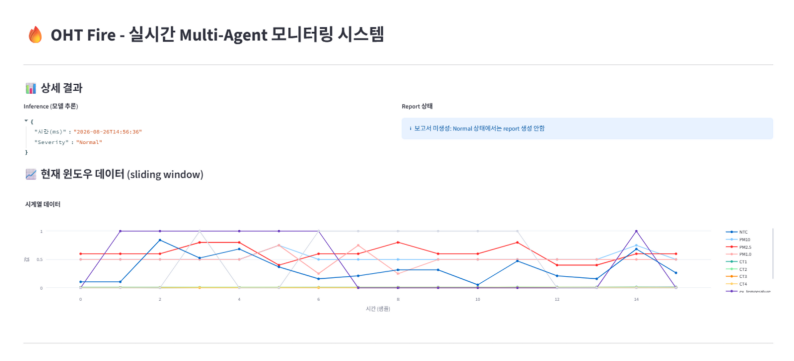

이미지에 표시된 OHT(Out of The Ordinary) Multi-Agent 모니터링 시스템의 슬라이딩 윈도우(sliding window) 차트 분석 결과는 다음과 같습니다.

**핵심 내용:**

*   **시간 (s):**  0초부터 14초까지의 데이터를 보여줍니다.
*   **Severity:**  각 지표(NTC, PM25, PM10, C13, C14)의 심각도를 나타냅니다.
*   **색상:**
    *   파란색: NTC (일반적으로 대기 오염 측정 지표)
    *   분홍색: PM25 (미세먼지)
    *   빨간색: PM10 (굵은 먼지)
    *   초록색: C13
    *   보라색: C14
*   **주요 특징:**
    *   **0-6초:** 모든 지표의 심각도가 정상 범위 (0.5 이내)에 머물러 있습니다.
    *   **6-12초:** NTC, PM25, PM10의 심각도가 급격히 증가하고, 심각도가 1에 근접하는 수준입니다.  특히 PM25와 PM10의 급증이 눈에 띱니다.
    *   **12-14초:**  NTC, PM25, PM10의 심각도가 다시 감소하지만, 여전히 심각한 수준입니다. C13, C14 지표는 비교적 안정적인 상태를 유지합니다.

**종합 해석:**

6초부터 12초 사이에 특정 지역에서 미세먼지 및 굵은 먼지(PM25, PM10) 농도가 급격히 증가하여 OHT 이상 감지 기준에 해당됩니다.  이는 심각한 대기 오염 상황을 의미하며, 추가적인 조사가 필요할 수 있습니다.

**참고:**

*   슬라이딩 윈도우는 특정 시간 동안의 데이터를 연속적으로 보여주는 방식입니다. 이를 통해 변화 추세를 파악하는 데 유용합니다.
*   OHT 시스템은 정상적인 데이터 패턴에서 벗어난 이상 징후를 자동으로 감지하는 시스템입니다.


In [17]:
# 사용 예시
# 1. 단일 이미지 분석
result = describe_image("./data/oht_dashboard.png", "이 이미지는 OHT 이상 감지 보고서입니다. 설명해주세요.")
print(result)

** 참고 **
* Huggingface로 Gemma3 4B 추론하기
- ollama는 ollama 지원 모델들만 지원 가능
- gemma 3 같은 경우도 개인 개발자들이 fine tuning 한게 많음
- 이런 것들은 허깅페이스에서 더 많은 경우를 볼 수 있음(도메인 특화된거 찾을 수 있음)

#### Langchain으로 ollama LLM 활용하기
- 이번에는 좀 더 가벼운 질문으로 가보자...

In [1]:
from langchain_ollama import ChatOllama

llm = ChatOllama(
    model="gemma3:4b",
    temperature=0,
    repeat_penalty=1.1,
)

messages = [
    (
        "system",
        "You are a helpful assistant",
    ),
    ("human", "안녕, 나는 내일 치킨랩을 먹을까 셀러드를 먹을까 조언해줘."),
]

ai_msg = llm.invoke(messages)
print(ai_msg.content)

안녕하세요! 내일 치킨랩과 샐러드 중 어떤 것을 먹을지 고민이시군요. 두 음식 모두 맛있지만, 몇 가지 고려할 사항이 있습니다.

**치킨랩:**

*   **장점:** 든든하고 맛있습니다. 특히 치킨과 밥, 소스가 잘 어울리는 조합이죠.
*   **단점:** 칼로리가 높고, 기름기가 많을 수 있습니다.
*   **추천 대상:** 배가 많이 고플 때, 든든하게 먹고 싶을 때

**샐러드:**

*   **장점:** 칼로리가 낮고, 건강에 좋습니다. 다양한 채소와 드레싱을 선택하여 맛을 조절할 수 있습니다.
*   **단점:** 치킨랩만큼 든든하지 않을 수 있습니다.
*   **추천 대상:** 건강을 생각하거나, 가볍게 식사하고 싶을 때

**결론:**

*   **만약 배가 고프다면:** 치킨랩을 추천합니다.
*   **만약 건강을 생각한다면:** 샐러드를 추천합니다.

어떤 음식이 더 끌리시나요? 아니면, 오늘 하루 어떤 활동을 계획하고 계신가요? 활동량에 따라 더 적절한 음식을 추천해 드릴 수 있습니다.


- 실시간으로 보여주는 (한번에 보여주는 형식이 아닌) stream

In [2]:
for chunk in llm.stream(messages):
    print(chunk.content, end="", flush=True)

안녕하세요! 내일 치킨랩과 샐러드 중 어떤 것을 먹을지 고민이시군요. 두 음식 모두 맛있지만, 몇 가지 고려할 사항이 있습니다.

**치킨랩:**

*   **장점:** 든든하고 맛있습니다. 특히 치킨과 밥, 소스가 잘 어울리는 조합이죠.
*   **단점:** 칼로리가 높고, 기름기가 많을 수 있습니다.
*   **추천 대상:** 배가 많이 고플 때, 든든하게 먹고 싶을 때

**샐러드:**

*   **장점:** 칼로리가 낮고, 건강에 좋습니다. 다양한 채소와 드레싱을 선택하여 맛을 조절할 수 있습니다.
*   **단점:** 치킨랩만큼 든든하지 않을 수 있습니다.
*   **추천 대상:** 건강을 생각하거나, 가볍게 식사하고 싶을 때

**결론:**

*   **만약 배가 고프다면:** 치킨랩을 추천합니다.
*   **만약 건강을 생각한다면:** 샐러드를 추천합니다.

어떤 음식이 더 끌리시나요? 아니면, 오늘 하루 어떤 활동을 계획하고 계신가요? 활동량에 따라 더 적절한 음식을 추천해 드릴 수 있습니다.

In [3]:
from langchain_ollama import ChatOllama
from langchain_core.messages import HumanMessage, SystemMessage
import base64
from PIL import Image
import io

# 이미지 데이터를 base64로 인코딩하는 함수
def encode_image_to_base64(image_path):
    with open(image_path, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode('utf-8')

# 이미지와 텍스트가 함께 있는 메시지 예시
image_path = "./data/duck.png"  # 실제 이미지 경로로 변경 필요
image_b64 = encode_image_to_base64(image_path)

# Ollama 멀티모달 모델 설정
llm = ChatOllama(
    model="gemma3:4b",
    temperature=0,
    repeat_penalty=1.1,
)

# 이미지와 텍스트가 함께 있는 메시지 구성 방법
multimodal_message = HumanMessage(
    content=[
        {
            "type": "image_url",
            "image_url": f"data:image/jpeg;base64,{image_b64}",
        },
        {
            "type": "text", 
            "text": "내가 가장 좋아하는 캐릭터야. 너가 볼때도 귀여워?"
        }
    ]
)

# 멀티모달 메시지 호출 예시
multimodal_response = llm.invoke([SystemMessage(content="You are a helpful assistant."), multimodal_message])
print(multimodal_response.content)

네, 정말 귀엽네요!  żół새의 웃는 모습이 너무 사랑스럽네요. 😊


오늘 공부도 끝!

깃에 올리자 ㅜㅜㅜ

